# Griffiths Ch. 7 → the Dispersion-GS Receiver

Chapter 7 (currents, RC circuits, EMF, induction) is not abstract here: it **is the analog front-end**
that turns the optical fields $I_1(t), I_2(t)$ into the numbers the Gerchberg-Saxton loop recovers
phase from. Each problem maps to a real part of the carrier-less receiver.

| Ch. 7 problem | result | role in the dispersion-GS receiver |
|---|---|---|
| 7.2 RC discharge | $Q=Q_0e^{-t/RC}$, $\tau=RC$ | the photodiode + amplifier **RC bandwidth** that samples $I_1,I_2$ |
| 7.3 charge relaxation | $\tau=\epsilon_0/\sigma$ | intrinsic response time of the detector semiconductor |
| 7.5 max power transfer | $R=r$ | **impedance match** detector $\to$ amplifier for best SNR on $I$ |
| 7.6 electrostatic EMF $=0$ | conservative | a path-independent (curl-free) phase has no net winding |
| 7.7 / 7.10 motional / rotating EMF | $\mathcal E = B\omega a^2\sin\omega t$ | the **photo-EMF** current source; sinusoidal modulation |
| 7.11 eddy-current braking | terminal velocity | the damped feedback of the laser-lock control loop |

The simulation below makes the headline one quantitative: the detector's RC bandwidth blurs $I_1,I_2$
and caps how well any algorithm recovers the phase. Engine: `gs_core` + SymPy.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math
from dgs import gs_core as gs
sp.init_printing(use_latex="mathjax")
print("loaded")

loaded


## 1 — The detector is an RC circuit (7.2, 7.3)

A photodiode feeding a transimpedance amplifier is exactly the RC of Problem 7.2: charge decays as
$Q(t)=Q_0e^{-t/RC}$ with time constant $\tau=RC$, and the **charge-relaxation time** of the
semiconductor itself is $\tau=\epsilon_0/\sigma$ (7.3). That $\tau$ is the receiver's bandwidth:
$f_c=1/2\pi RC$. Anything in $I_1,I_2$ faster than $f_c$ is smeared out before it is ever digitised.

In [2]:
t, R, C, Q0, sigma, eps0 = sp.symbols("t R C Q_0 sigma epsilon_0", positive=True)
Qf = sp.Function("Q")
sol = sp.dsolve(sp.Eq(Qf(t).diff(t), -Qf(t)/(R*C)), Qf(t), ics={Qf(0): Q0})
display(Math(r"\text{7.2: } " + sp.latex(sol) + r",\quad \tau = RC"))
display(Math(r"\text{7.3 charge relaxation: } \tau = \frac{\epsilon_0}{\sigma}"
             r"\quad\Rightarrow\quad f_c = \frac{1}{2\pi RC}\ \text{(detector bandwidth)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2 — Detector bandwidth caps the recovered phase

Take the two measured intensities, pass them through the detector's RC low-pass
$H(f)=1/(1+jf/f_c)$, then run Gerchberg-Saxton. A slow detector (low $f_c$) blurs the fine structure
that carries the phase, and recovery collapses; once $f_c$ clears the signal's bandwidth, recovery
saturates. The carrier-less receiver lives or dies on detector bandwidth.

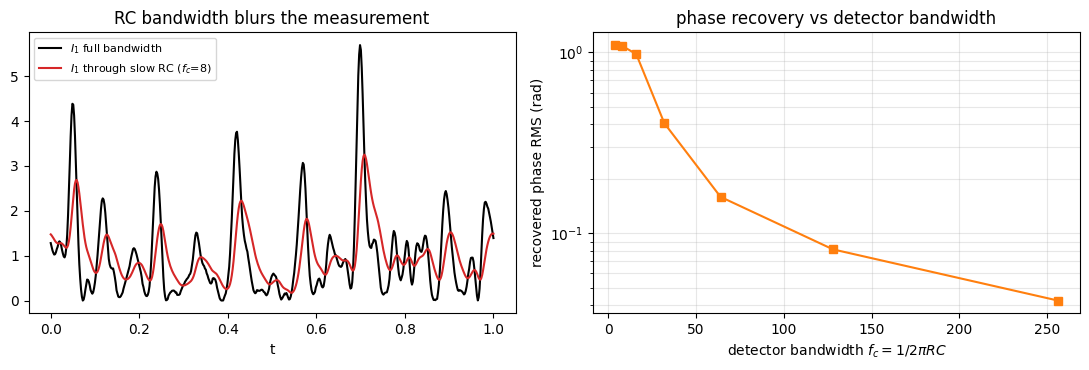

  fc=  4: phase RMS 1.098 rad
  fc=  8: phase RMS 1.086 rad
  fc= 16: phase RMS 0.980 rad
  fc= 32: phase RMS 0.406 rad
  fc= 64: phase RMS 0.159 rad
  fc=128: phase RMS 0.082 rad
  fc=256: phase RMS 0.043 rad


In [3]:
data = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=40.0)
I1, I2, phi_true, D1, D2 = data["I1"], data["I2"], data["phi_true"], data["D1"], data["D2"]
N = len(I1); fs = N      # normalized sample rate

def rc_lowpass(sig, fc):
    f = np.fft.fftfreq(N, 1/fs)
    H = 1.0 / (1 + 1j*f/fc)
    return np.real(np.fft.ifft(np.fft.fft(sig) * H))

def align_rms(phi_rec):
    best = 1e9
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j*(phi_true - s*phi_rec))))
        best = min(best, np.sqrt(np.mean(np.angle(np.exp(1j*(phi_true-(s*phi_rec+off))))**2)))
    return best

fcs = np.array([4, 8, 16, 32, 64, 128, 256])
rms = []
for fc in fcs:
    I1f, I2f = np.maximum(rc_lowpass(I1, fc), 0), np.maximum(rc_lowpass(I2, fc), 0)
    phi_rec, _ = gs.retrieve_phase(I1f, I2f, D1, D2, n_iter=80, unit_amplitude=True)
    rms.append(align_rms(phi_rec))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
tt = data["t"]
ax[0].plot(tt, I1, "k", lw=1.5, label="$I_1$ full bandwidth")
ax[0].plot(tt, rc_lowpass(I1, 8), "C3", label="$I_1$ through slow RC ($f_c$=8)")
ax[0].set_title("RC bandwidth blurs the measurement"); ax[0].legend(fontsize=8); ax[0].set_xlabel("t")
ax[1].semilogy(fcs, rms, "s-", color="C1")
ax[1].set_xlabel("detector bandwidth $f_c = 1/2\\pi RC$"); ax[1].set_ylabel("recovered phase RMS (rad)")
ax[1].set_title("phase recovery vs detector bandwidth"); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for f, r in zip(fcs, rms):
    print(f"  fc={f:>3}: phase RMS {r:.3f} rad")

## 3 — Max power transfer = the impedance match (7.5)

Problem 7.5 finds that a source of internal resistance $r$ delivers maximum power into a load when
$R=r$. In the receiver this is the **impedance match** between the photodiode and the transimpedance
amplifier: matched, the largest signal current reaches the ADC, maximising the SNR of $I_1,I_2$ — and
SNR is what set the recovery floor in the ADC-bits notebook.

<IPython.core.display.Math object>

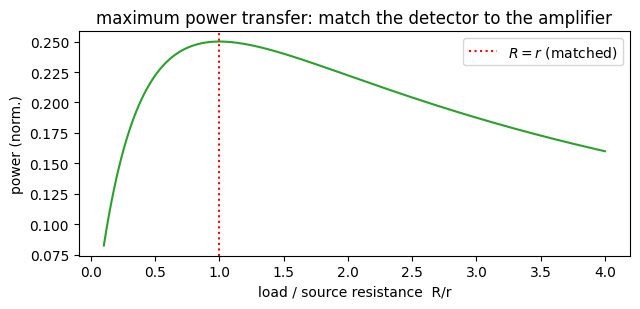

In [4]:
r, R = sp.symbols("r R", positive=True); E = sp.Symbol("E", positive=True)
P = E**2 * R / (R + r)**2                      # power in the load
Rbest = sp.solve(sp.diff(P, R), R)
display(Math(r"P(R) = " + sp.latex(P) + r",\quad \frac{dP}{dR}=0 \Rightarrow R = " + sp.latex(Rbest[0])
             + r"\quad(\text{match load to source})"))
Rs = np.linspace(0.1, 4, 200)
plt.figure(figsize=(6.5, 3.2))
plt.plot(Rs, Rs/(Rs+1)**2, "C2"); plt.axvline(1, color="r", ls=":", label="$R=r$ (matched)")
plt.xlabel("load / source resistance  R/r"); plt.ylabel("power (norm.)"); plt.legend()
plt.title("maximum power transfer: match the detector to the amplifier")
plt.tight_layout(); plt.show()

## 4 — The photo-EMF and the rotating-loop generator (7.7, 7.10)

A photodiode is a light-driven current source — its "EMF" is set by the incident optical power, the
optical analog of the motional EMF in the bar (7.7). And the rotating loop (7.10) gives a *sinusoidal*
$\mathcal E=B\omega a^2\sin\omega t$ — the same shape as a sinusoidally phase-modulated optical
carrier, whose Bessel sidebands the FM notebook analysed. Conservative fields give $\mathcal E=0$
(7.6): a path-independent optical phase has no net winding, the well-posed baseline for recovery.

In [5]:
Bf, w, a = sp.symbols("B omega a", positive=True); tt2 = sp.Symbol("t")
Phi = Bf * sp.pi*a**2 * sp.cos(w*tt2)          # flux through a loop rotating in B
emf = -sp.diff(Phi, tt2)
display(Math(r"\text{7.10: } \mathcal E = -\frac{d\Phi}{dt} = " + sp.latex(emf)
             + r"\ \sim\ B\omega a^2\sin\omega t\quad(\text{sinusoidal, like a PM optical carrier})"))

<IPython.core.display.Math object>

## 5 — The whole chapter is the receiver's front end

Stitching it together: light hits a photodiode (a **photo-EMF** current source, 7.7), the diode +
amplifier form an **RC** low-pass whose $\tau=RC$ / charge-relaxation $\epsilon_0/\sigma$ sets the
**bandwidth** (7.2/7.3) — and §2 showed that bandwidth directly caps the recovered phase. You
**impedance-match** detector to amplifier for max SNR (7.5), and the **control loop** that locks the
laser is a damped, eddy-current-like feedback (7.11). Griffiths Ch. 7 is, almost line for line, the
analog electronics between the fibre and the Gerchberg-Saxton code in `gs_core.py`.

Built on `gs_core` (`make_qpsk_measurements`, `retrieve_phase`) + SymPy for the Ch. 7 results.